# Q4 - Language Backgroud and Deprivation 

**Research Question:** How does the performance of pupils with English as an Additional Language (EAL) compare to first-language English speakers across different deprivation levels?

This noteboook will examine attainment levels amongst pupils with English as an Additional Language compared to those whom English is their first-lanaguage and any changes across levels of deprivation using the IMD score comparatively with IDACI scores.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [111]:
#Importing cleaned dataset 

df = pd.read_csv("data/final_df_lang.csv")

df.columns
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nEnglish as a First Language: {df['first_language'].unique()}")
print(f"Years covered:  {sorted(df['end_year'].unique())}")
print(f"Local Authorities: {df['new_la_code'].nunique()}")

Shape: (2084, 28)

Columns: ['time_period', 'new_la_code', 'la_name', 'pupil_count', 'first_language', 'attainment8_average', 'ebacc_aps_average', 'attainment8eng_average', 'attainment8mat_average', 'attainment8ebacc_average', 'ebacceng_aps_average', 'ebaccmat_aps_average', 'ebaccsci_aps_average', 'ebacchum_aps_average', 'ebacclan_aps_average', 'end_year', 'merge_la_code', 'UTLA19CD', 'UTLA19NM', 'imd_score', 'income_score', 'employment_score', 'health_score', 'crime_score', 'barriers_score', 'living_env_score', 'idaci_score', 'children_subdomain']

English as a First Language: <StringArray>
['Known or believed to be English', 'Known or believed to be other than English']
Length: 2, dtype: str
Years covered:  [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Local Authorities: 153


In [ ]:
#Confirming correct columns are present 

q5=df[[ "end_year",
    "la_name",
    "first_language",
    "attainment8_average",
    "imd_score",
    "idaci_score"
]].copy()

q5.head(50)

,end_year,la_name,first_language,attainment8_average,imd_score,idaci_score
0,2025,Hartlepool,Known or believed to be English,42.3,34.853121,0.266483
1,2025,Hartlepool,Known or believed to be other than English,45.8,34.853121,0.266483
2,2025,Middlesbrough,Known or believed to be English,40.7,40.443116,0.300384
3,2025,Middlesbrough,Known or believed to be other than English,43.5,40.443116,0.300384
4,2025,Redcar and Cleveland,Known or believed to be English,44.2,29.841330,0.232955
5,2025,Redcar and Cleveland,Known or believed to be other than English,48.1,29.841330,0.232955
6,2025,Stockton-on-Tees,Known or believed to be English,44.4,25.244108,0.194075
7,2025,Stockton-on-Tees,Known or believed to be other than English,52.1,25.244108,0.194075
8,2025,Darlington,Known or believed to be English,43.7,26.787000,0.200677
9,2025,Darlington,Known or believed to be other than English,49.6,26.787000,0.200677


In [112]:
#Creating data frame for analysis 
df['deprivation_group'] = pd.qcut(df['imd_score'],
                                  q=5,
                                  labels=['Least deprived',
                                          'Low',
                                          'Medium',
                                          'High',
                                          'Most deprived'])



In [113]:
#Least to Most deprived attainment based on fist language spoken 
summary = (
    df.groupby(['deprivation_group', 'first_language'])
      ['attainment8_average']
      .mean()
      .reset_index()
)

print(summary)

  deprivation_group                              first_language  \
0    Least deprived             Known or believed to be English   
1    Least deprived  Known or believed to be other than English   
2               Low             Known or believed to be English   
3               Low  Known or believed to be other than English   
4            Medium             Known or believed to be English   
5            Medium  Known or believed to be other than English   
6              High             Known or believed to be English   
7              High  Known or believed to be other than English   
8     Most deprived             Known or believed to be English   
9     Most deprived  Known or believed to be other than English   

   attainment8_average  
0            50.596698  
1            53.667453  
2            48.333649  
3            51.293365  
4            48.226699  
5            50.184466  
6            46.777143  
7            49.043333  
8            43.753695  
9           

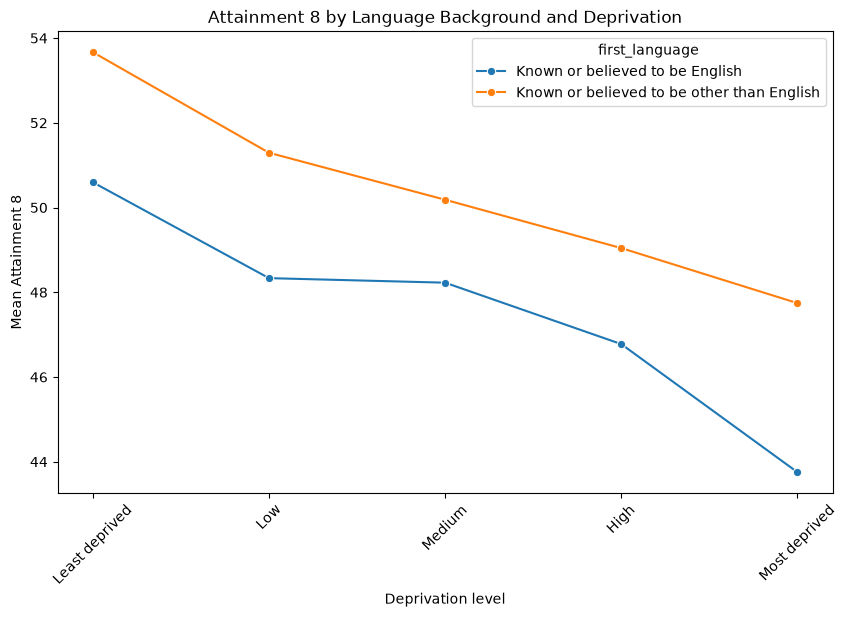

In [ ]:
#Creating linegraph for mean attainment across EAL and English speakers 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(
    data=summary,
    x='deprivation_group',
    y='attainment8_average',
    hue='first_language',
    marker='o'
)

plt.xlabel('Deprivation level')
plt.ylabel('Mean Attainment 8')
plt.title('Attainment 8 by Language Background and Deprivation')
plt.xticks(rotation=45)
plt.show()

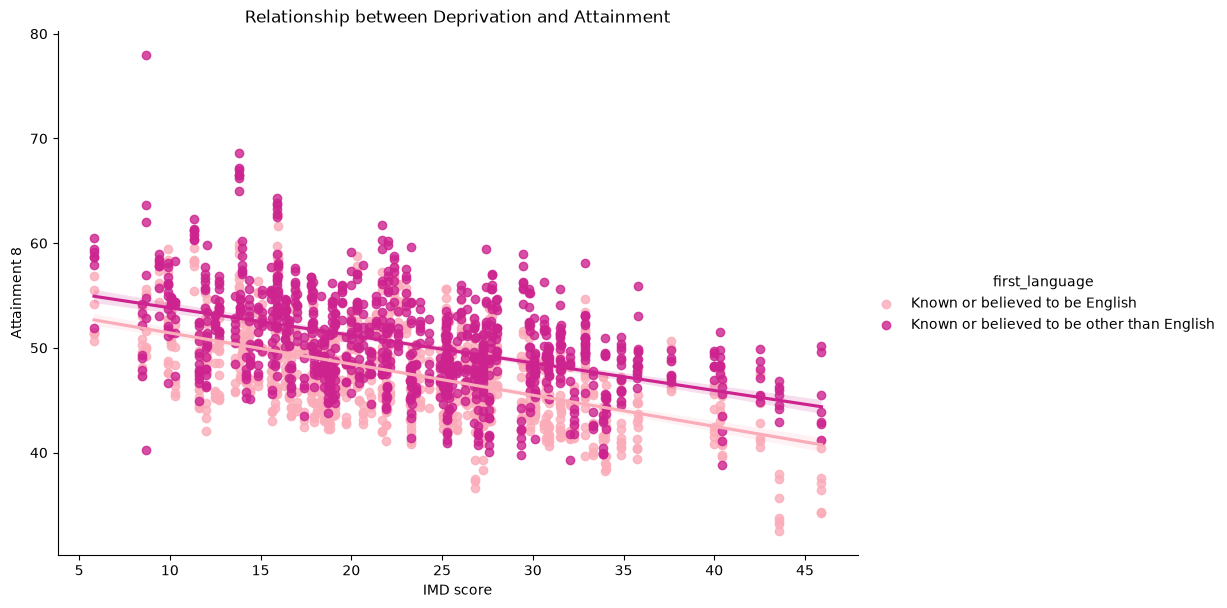

In [ ]:
#Scatter plot to assess relationship between Deprivation and Attainment 

sns.lmplot(
    data=df,
    x='imd_score',
    y='attainment8_average',
    hue='first_language',
    palette= 'RdPu',
    height=6,
    aspect=1.5
)

plt.xlabel('IMD score')
plt.ylabel('Attainment 8')
plt.title('Relationship between Deprivation and Attainment')
plt.show()

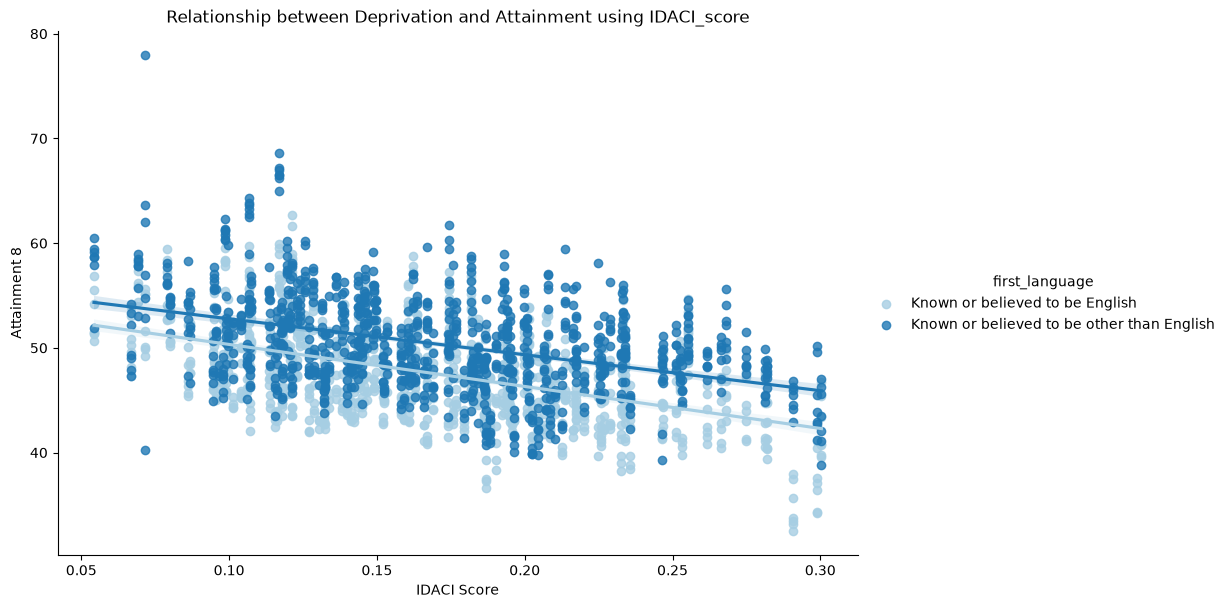

In [116]:
#Scatter plot to assess relationship between Deprivation and Attainment using IDACI scores
sns.lmplot(
    data=df,
    x='idaci_score',
    y='attainment8_average',
    hue='first_language',
    palette= 'Paired',
    height=6,
    aspect=1.5
)

plt.xlabel('IDACI Score')
plt.ylabel('Attainment 8')
plt.title('Relationship between Deprivation and Attainment using IDACI_score')
plt.show()

The reason for using the IDACI Score was to assess the impact of deprivation on children living in income deprived households and to see if disparity influenced English as an additional language (EAL) pupils and English Speaking pupils in their attainment. 

From these two graphs, it is clear to see that where deprivation is higher, attainment falls for both groups but EAL pupils consistently outperform pupils whose first language is English across all level of deprivation.


In [92]:
from scipy.stats import linregress

english = df[df['first_language'] == 'Known or believed to be English']

result = linregress(
    english['imd_score'],
    english['attainment8_average']
)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)

Slope: -0.29739607087171155
Intercept: 54.40273216867473
R-squared: 0.28499456958086966
P-value: 8.048559925068924e-78


In [93]:
eal = df[df['first_language'] == 'Known or believed to be other than English']

result = linregress(
    eal['imd_score'],
    eal['attainment8_average']
)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)

Slope: -0.26323778360407085
Intercept: 56.4628903091287
R-squared: 0.21044143746547803
P-value: 2.344575435026986e-55


In [95]:
from scipy.stats import linregress

english = df[df['first_language'] == 'Known or believed to be English']

result = linregress(
    english['idaci_score'],
    english['attainment8_average']
)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)

Slope: -40.10962761264675
Intercept: 54.34015773509139
R-squared: 0.23893718328385558
P-value: 1.1003267683435011e-63


In [97]:
eal = df[df['first_language'] == 'Known or believed to be other than English']

result = linregress(
    eal['idaci_score'],
    eal['attainment8_average']
)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-squared:", result.rvalue**2)
print("P-value:", result.pvalue)

Slope: -34.30054213658375
Intercept: 56.2044954898988
R-squared: 0.16468616836518316
P-value: 1.3955047827113143e-42


Linear regression analysis showed negative relationships for both IMD Score and Attainment average and between IDACI Scores and Attainment average- indicating that higher levels of depreciation are associated with lower education attainment. Both sets of analysis using the IMD scores and IDACI scores show that EAL pupils consistently achieve similar or higher attainment scores across deprivation levels.

### Findings

Pupils with English as an Additional Language (EAL) generally showed different patterns of attainment compared with first-language English speakers across deprivation levels. Deprivation had a strong impact on both groups, with performance declining as deprivation increased. However, the gap between EAL and first-language English pupils varied by deprivation level. In the least deprived groups, first-language English pupils tended to achieve slightly higher outcomes, whereas in more deprived groups the difference narrowed and, in some cases, EAL pupils performed similarly to or better than their English-speaking peers. Overall, socio-economic deprivation appeared to have a greater influence on attainment than language background alone.